In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
from pyvi import ViTokenizer

# Cài đặt hiển thị đồ thị
%matplotlib inline
sns.set_theme(style="whitegrid")

In [59]:
# Tải dữ liệu
df = pd.read_csv('movie_reviews.csv')
# Xem 5 dòng đầu tiên
display(df.head())
df['comment'] = df['comment'].fillna("không_bình_luận")

,rating,comment,Movie_Title,Movie_URL
0,10,Thật sự mình thích cái cách Trấn Thành đem thể...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
1,10,Thỏ Ơi là một làn gió mới đầy trẻ trung với đi...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
2,10,Lời khuyên cho mấy cặp đôi đang yêu nhau thì k...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
3,10,"Phim của Trấn Thành công nhận là có hơi “chợ”,...",Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
4,9,Dạo này mình hay quên trước quên sau nên đi co...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review


C:\Users\admin\AppData\Local\Temp\ipykernel_7928\449394091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


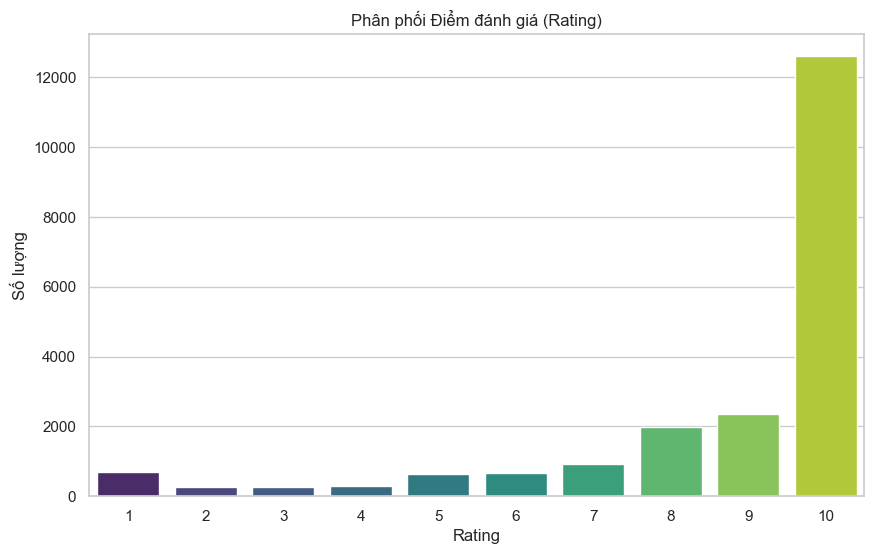

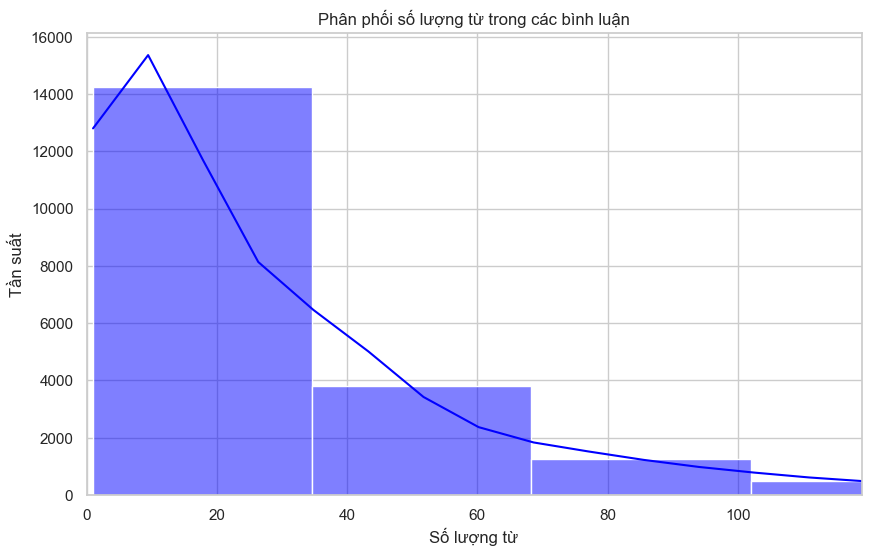

C:\Users\admin\AppData\Local\Temp\ipykernel_7928\449394091.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_movies.index, x=top_movies.values, palette='magma')


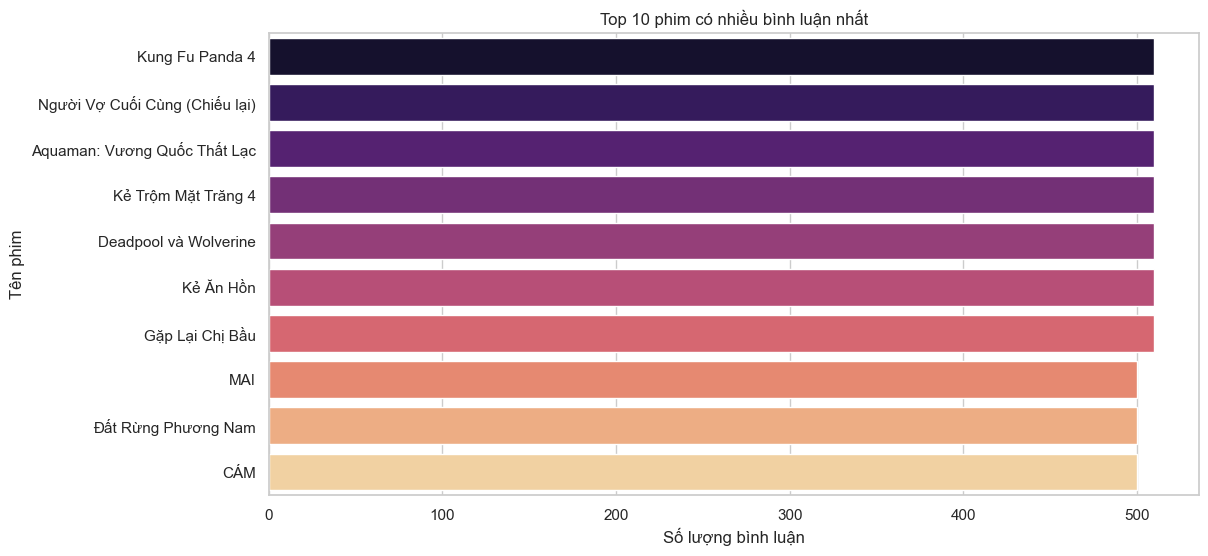

In [60]:
# 1. Biểu đồ phân phối Rating (Điểm đánh giá)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Phân phối Điểm đánh giá (Rating)')
plt.xlabel('Rating')
plt.ylabel('Số lượng')
plt.show()

# 2. Thống kê chiều dài của Comment (số lượng từ)
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='blue')
plt.title('Phân phối số lượng từ trong các bình luận')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')
plt.xlim(0, df['word_count'].quantile(0.95)) # Cắt đuôi để biểu đồ dễ nhìn hơn (hiển thị 95% dữ liệu)
plt.show()

# 3. Top 10 phim có nhiều đánh giá nhất
plt.figure(figsize=(12, 6))
top_movies = df['Movie_Title'].value_counts().head(10)
sns.barplot(y=top_movies.index, x=top_movies.values, palette='magma')
plt.title('Top 10 phim có nhiều bình luận nhất')
plt.xlabel('Số lượng bình luận')
plt.ylabel('Tên phim')
plt.show()

In [61]:
import requests
import re
import emoji
from pyvi import ViTokenizer

url = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
response = requests.get(url)

vietnamese_stopwords = set([line.strip().replace(" ", "_") for line in response.text.split('\n') if line])
important_sentiment_words = {
    "hay", "quá", "tốt", "đỉnh", "tuyệt", "tuyệt_vời", "xuất_sắc", "ổn", 
    "dở", "tệ", "chê", "chán", "buồn", "vui", "thích", "ghét", "sợ",
    "không", "chưa", "chẳng", "đẹp", "mới", "cảm_động", "hấp_dẫn"
}
    
vietnamese_stopwords = vietnamese_stopwords - important_sentiment_words   

VOWELS = r'[aeiouyáàảãạâấầẩẫậăắằẳẵặéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ]'

TEENCODE_DICT = {
    "ah" : "à" ,"ko": "không", "k": "không", "kh": "không", "khong": "không", "khum": "không", "hông": "không",
    "dc": "được", "đc": "được", "đx": "được", "dk": "được",
    "vs": "với", "mng": "mọi người", "mn": "mọi người",
    "mik": "mình", "m": "mình", "t": "tôi", "tui": "tôi",
    "nma": "nhưng mà", "ròi": "rồi", "rùi": "rồi", "r": "rồi",
    "típ": "tiếp", "cx": "cũng", "bt": "bình thường", "nx": "nữa",
    "lun": "luôn", "thui": "thôi", "ksao": "không sao",
    "okela": "ok", "oke": "ok", "oki": "ok",
    "nhìu": "nhiều", "flim": "phim", "film": "phim",
    "ngta": "người ta", "mqh": "mối quan hệ", "ny": "người yêu",
    "nvat": "nhân vật", "vde": "vấn đề", "qcao": "quảng cáo" , "cũm": "cũng"
}

def clean_vietnamese_text_final(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s\u00C0-\u1EF9]', ' ', text)
    text = text.replace('thu gọn', '')
    
    text = re.sub(r'(á|à|ả|ã|ạ|â|ấ|ầ|ẩ|ẫ|ậ|ă|ắ|ằ|ẳ|ẵ|ặ)a+', r'\1', text)
    text = re.sub(r'(ó|ò|ỏ|õ|ọ|ô|ố|ồ|ổ|ỗ|ộ|ơ|ớ|ờ|ở|ỡ|ợ)o+', r'\1', text)
    text = re.sub(r'(é|è|ẻ|ẽ|ẹ|ê|ế|ề|ể|ễ|ệ)e+', r'\1', text)
    text = re.sub(r'(í|ì|ỉ|ĩ|ị)i+', r'\1', text)
    text = re.sub(r'(ú|ù|ủ|ũ|ụ|ư|ứ|ừ|ử|ữ|ự)u+', r'\1', text)
    text = re.sub(r'(ý|ỳ|ỷ|ỹ|ỵ)y+', r'\1', text)
    text = re.sub(r'([a-z\u00C0-\u1EF9])\1+', r'\1', text)
    
    text = re.sub(r'[^\w\s\u00C0-\u1EF9]', ' ', text)
    
    words = text.split()
    valid_words = []
    for word in words:
        if word in TEENCODE_DICT:
            word = TEENCODE_DICT[word]
            
        if " " not in word and len(word) > 10:
            continue
        if not re.search(VOWELS, word):
            continue
        valid_words.append(word)
        
    filtered_text = ' '.join(valid_words)
    tokenized_text = ViTokenizer.tokenize(filtered_text)
    
    final_words = tokenized_text.split()
    clean_words = [w for w in final_words if w not in vietnamese_stopwords]
    
    return ' '.join(clean_words)

In [62]:
# 1. Áp dụng hàm làm sạch tổng hợp
df['clean_comment'] = df['comment'].apply(clean_vietnamese_text_final)

# 2. Xử lý các comment bị rỗng hoặc quá ngắn (< 2 từ) sau khi làm sạch
def handle_empty_comments(text):
    if len(str(text).split()) < 2:
        return "không_bình_luận"
    return text

df['clean_comment'] = df['clean_comment'].apply(handle_empty_comments)

# 3. Lọc lấy các cột cần thiết (LẤY TRỰC TIẾP TỪ df, KHÔNG DÙNG df_clean NỮA)
final_df = df[['rating', 'clean_comment', 'Movie_Title']]

# 4. Hiển thị 10 kết quả đầu tiên để kiểm tra
display(final_df.head(10))

# 5. Lưu kết quả ra file CSV chuẩn
output_filename = 'movie_reviews_cleaned.csv'
final_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

,rating,clean_comment,Movie_Title
0,10,thích trấn thành đem thể_loại thriler màn_ảnh ...,Thỏ Ơi!!
1,10,thỏ làn gió mới trẻ_trung rực_rỡ nằm hình_ảnh ...,Thỏ Ơi!!
2,10,khuyên mấy cặp đôi yêu không đi thỏ chột_dạ lắ...,Thỏ Ơi!!
3,10,phim trấn thành_công_nhận hơi chợ không phim c...,Thỏ Ơi!!
4,9,dạo hay quên quên đi coi phim quên review phim...,Thỏ Ơi!!
5,9,trấn thành dàn cast đỉnh quá diễn tròn vai sợ ...,Thỏ Ơi!!
6,10,phim thỏ mới rời đi có_lí_do sống câu không đá...,Thỏ Ơi!!
7,10,phim hay cảm_động tình_yêu diễn_viên phim đa_p...,Thỏ Ơi!!
8,10,chê chê phim nhàm hay dàn diễn_viên diễn chưa ...,Thỏ Ơi!!
9,10,tinh_hoa hội_tụ phim kịch_bản hay đạo_diễn_xuấ...,Thỏ Ơi!!
